In [1]:
import numpy as np
import matplotlib.pyplot as plt
import wfdb
import glob
import random
import gc
import mne
from scipy.signal import find_peaks
import re
import tqdm
import logging
import os
from sklearn import model_selection

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader,Dataset
import numpy as np
from sklearn import metrics
import matplotlib.pyplot as plt

In [2]:
ch_labels = ['FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1', 'FP1-F3', 'F3-C3', 'C3-P3','P3-O1','FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'FP2-F8', 'F8-T8', 'T8-P8', 'P8-O2','FZ-CZ', 'CZ-PZ']

In [3]:
path2pt = 'A:\chb-mit-scalp-eeg-database-1.0.0'

folders = sorted(glob.glob(path2pt+'\\*\\'))
n_patients = [m[-2:] for m in [l.rsplit('\\',2)[-2] for l in folders]]
print(*n_patients)

01 02 03 04 05 06 07 08 09 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24


In [4]:
random.seed(2023)
ratio_train = 0.8
train_patient_str = sorted(random.sample(n_patients, round(ratio_train*len(n_patients))))
test_patient_str = sorted([l for l in n_patients if l not in train_patient_str])
print('Train PT: ', *train_patient_str)
print('Test PT: ', *test_patient_str)

Train PT:  02 03 04 05 06 09 11 12 13 14 15 16 17 18 19 20 21 23 24
Test PT:  01 07 08 10 22


In [5]:
files_train = []
for l in train_patient_str:
    files_train = files_train+glob.glob(path2pt+'/chb{}/*.edf'.format(l))
    
files_test = []
for l in test_patient_str:
    files_test = files_test + glob.glob(path2pt+'/chb{}/*.edf'.format(l))

In [6]:
len(files_train), len(files_test)

(549, 137)

In [7]:
mne.set_log_level(verbose='ERROR')

In [8]:
temp_edf = mne.io.read_raw_edf("A:/chb-mit-scalp-eeg-database-1.0.0/chb07/chb07_12.edf")
temp_edf

<RawEDF | chb07_12.edf, 23 x 3686400 (14400.0 s), ~27 kB, data not loaded>

In [9]:
temp_edf.ch_names

['FP1-F7',
 'F7-T7',
 'T7-P7',
 'P7-O1',
 'FP1-F3',
 'F3-C3',
 'C3-P3',
 'P3-O1',
 'FP2-F4',
 'F4-C4',
 'C4-P4',
 'P4-O2',
 'FP2-F8',
 'F8-T8',
 'T8-P8-0',
 'P8-O2',
 'FZ-CZ',
 'CZ-PZ',
 'P7-T7',
 'T7-FT9',
 'FT9-FT10',
 'FT10-T8',
 'T8-P8-1']

In [10]:
sum([any([0 if re.match(c, l)==None else 1 for l in temp_edf.ch_names]) for c in ch_labels])==len(ch_labels)

True

In [11]:
emp_is_sz = np.zeros((temp_edf.n_times,))
emp_is_sz.shape

(3686400,)

In [12]:
temp_is_sz = np.zeros((temp_edf.n_times,))
temp_annotation = wfdb.rdann('A:/chb-mit-scalp-eeg-database-1.0.0/chb07/chb07_12.edf','seizures')
for i in range(int(temp_annotation.sample.size/2)):
    temp_is_sz[temp_annotation.sample[i*2]:temp_annotation.sample[i*2+1]]=1
temp_is_sz

array([0., 0., 0., ..., 0., 0., 0.])

In [13]:
# time_step = 4
# step = time_step*fs
# time_window = 8
# fs = int(1/(temp_edf.times[1]-temp_edf.times[0]))
# step_window = time_window*fs
# temp_len = temp_edf.n_times
# temp_is_sz_ind = np.array(
#         [temp_is_sz[i*step:i*step+step_window].sum()/step_window for i in range((temp_len-step_window)//step)]
#         )

In [14]:
# import pandas as pd
# pd.DataFrame(temp_is_sz_ind).value_counts()

In [15]:
# np.where(temp_is_sz_ind>0)[0].size

In [16]:
# temp_0_sample_size = round(0.01*np.where(temp_is_sz_ind==0)[0].size)
# temp_1_sample_size = np.where(temp_is_sz_ind>0)[0].size
        
# counter = counter + temp_0_sample_size + temp_1_sample_size
# counter

In [17]:
# array_signals = np.zeros((counter, len(ch_labels), step_window), dtype=np.float32)
# array_is_sz = np.zeros(counter, dtype=bool)

In [18]:
# array_signals.shape

In [20]:
logger = logging.getLogger(__name__)
fh = logging.FileHandler('read_files.log')
logger.addHandler(fh)

time_window = 8
time_step = 4

if os.path.exists('A:\\chbmitprocessed\\signal_samples.npy')&os.path.exists('A:\\chbmitprocessed\\is_sz.npy'):
    array_signals=np.load('A:\\chbmitprocessed\\signal_samples.npy')
    array_is_sz=np.load('A:\\chbmitprocessed\\is_sz.npy')
else:
    p = 0.01  
    counter = 0
    for temp_f in files_train:
        temp_edf =  mne.io.read_raw_edf(temp_f)
        temp_labels = temp_edf.ch_names
        if sum([any([0 if re.match(c, l)==None else 1 for l in temp_edf.ch_names]) for c in ch_labels])==len(ch_labels):
            time_window = 8
            time_step = 4
            fs = int(1/(temp_edf.times[1]-temp_edf.times[0]))
            step_window = time_window*fs
            step = time_step*fs
            
            temp_is_sz = np.zeros((temp_edf.n_times,))
            if os.path.exists(temp_f+'.seizures'):
                temp_annotation = wfdb.rdann(temp_f, 'seizures')
                for i in range(int(temp_annotation.sample.size/2)):
                    temp_is_sz[temp_annotation.sample[i*2]:temp_annotation.sample[i*2+1]]=1
            temp_len = temp_edf.n_times
            
            temp_is_sz_ind = np.array(
                [temp_is_sz[i*step:i*step+step_window].sum()/step_window for i in range((temp_len-step_window)//step)]
            )

            temp_0_sample_size = round(p*np.where(temp_is_sz_ind==0)[0].size)
            temp_1_sample_size = np.where(temp_is_sz_ind>0)[0].size

            counter = counter + temp_0_sample_size + temp_1_sample_size
        temp_edf.close()

    array_signals = np.zeros((counter, len(ch_labels), step_window), dtype=np.float32)
    array_is_sz = np.zeros(counter, dtype=bool)

    counter = 0
    for n, temp_f in enumerate(tqdm.tqdm(files_train)):
        to_log = 'No. {}: Reading. '.format(n)
        temp_edf =  mne.io.read_raw_edf(temp_f)
        temp_labels = temp_edf.ch_names
        n_label_match = sum([any([0 if re.match(c, l)==None else 1 for l in temp_edf.ch_names]) for c in ch_labels])
        if n_label_match==len(ch_labels):
            ch_mapping = {sorted([l for l in temp_edf.ch_names if re.match(c, l)!=None ])[0]:c for c in ch_labels}
            temp_edf.rename_channels(ch_mapping)
            #temp_edf = temp_edf.pick(ch_labels)

            temp_is_sz = np.zeros((temp_edf.n_times,))
            temp_signals = temp_edf.get_data(picks=ch_labels)*1e6

            if os.path.exists(temp_f+'.seizures'):
                to_log = to_log+'sz exists.'
                temp_annotation = wfdb.rdann(temp_f, 'seizures')
                for i in range(int(temp_annotation.sample.size/2)):
                    temp_is_sz[temp_annotation.sample[i*2]:temp_annotation.sample[i*2+1]]=1
            else:
                to_log = to_log+'No sz.'

            temp_len = temp_edf.n_times

            time_window = 8
            time_step = 4
            fs = int(1/(temp_edf.times[1]-temp_edf.times[0]))
            step_window = time_window*fs
            step = time_step*fs

            temp_is_sz_ind = np.array(
                [temp_is_sz[i*step:i*step+step_window].sum()/step_window for i in range((temp_len-step_window)//step)]
            )
            del temp_is_sz

            temp_0_sample_size = round(p*np.where(temp_is_sz_ind==0)[0].size)
            temp_1_sample_size = np.where(temp_is_sz_ind>0)[0].size

            # sz data
            temp_ind = list(np.where(temp_is_sz_ind>0)[0])
            for i in temp_ind:
                array_signals[counter, :, :] = temp_signals[:, i*step:i*step+step_window]
                array_is_sz[counter] = True
                counter = counter+1

            # no sz data
            temp_ind = random.sample(list(np.where(temp_is_sz_ind==0)[0]), temp_0_sample_size)
            for i in temp_ind:
                array_signals[counter, :, :] = temp_signals[:, i*step:i*step+step_window]
                array_is_sz[counter] = False
                counter = counter+1

            to_log += '{} signals added: {} w/o sz, {} w/ sz.'.format(
                temp_0_sample_size+temp_1_sample_size, temp_0_sample_size, temp_1_sample_size
            )

        else:
            to_log += 'Not appropriate channel labels. Reading skipped.'.format(n)
        
        logger.info(to_log)
        temp_edf.close()

        if n%10==0:
            gc.collect()
    gc.collect()
    
    np.save('signal_samples', array_signals)
    np.save('is_sz', array_is_sz)

array_signals = array_signals[:,:,::2]

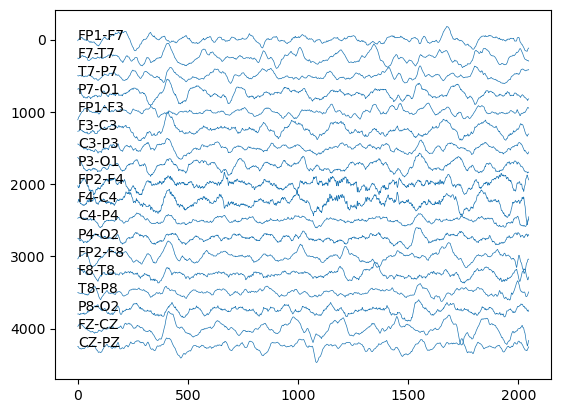

In [21]:
vertical_width = 250
signals = array_signals[-1,:,:]

fig, ax = plt.subplots()
for i in range(signals.shape[0]):
    ax.plot(np.arange(signals.shape[-1]),signals[i,:]+i*vertical_width,linewidth=0.5,color='tab:blue')
    ax.annotate(ch_labels[i],xy=(0,i*vertical_width))
ax.invert_yaxis()
plt.show()

In [22]:
array_n = np.where(array_is_sz>.0)[0]
print('Number of all the extracted signals: {}'.format(array_is_sz.size))
print('Number of signals with seizures: {}'.format(array_n.size))
print('Ratio of signals with seizures: {:.3f}'.format(array_n.size/array_is_sz.size))

Number of all the extracted signals: 9505
Number of signals with seizures: 2581
Ratio of signals with seizures: 0.272


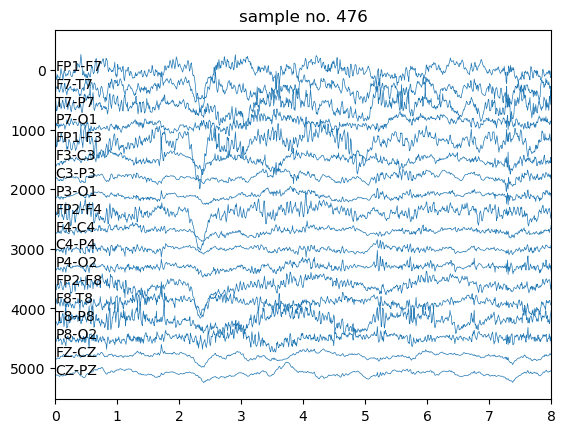

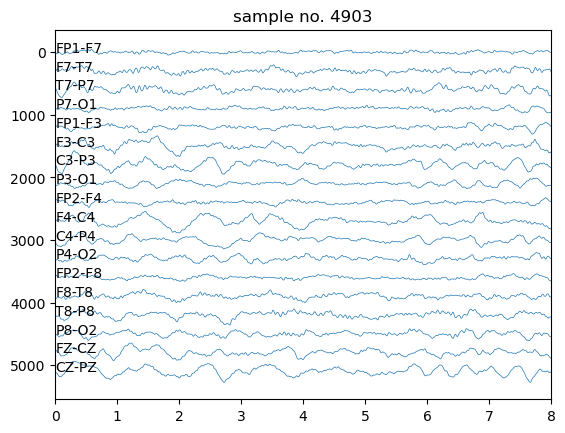

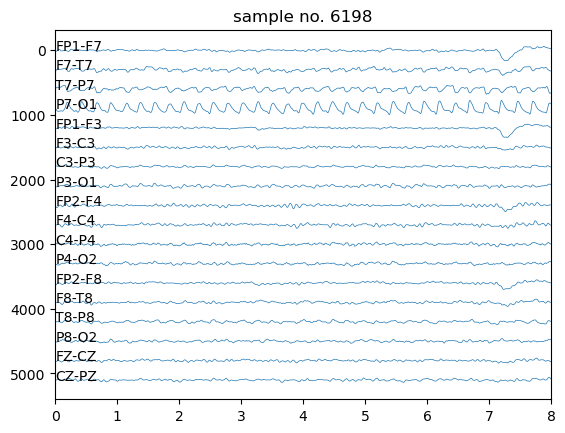

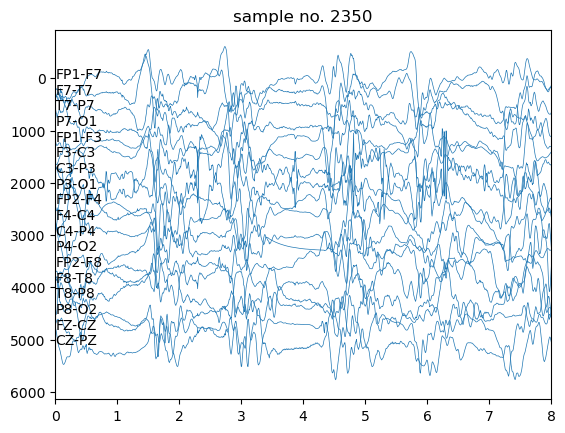

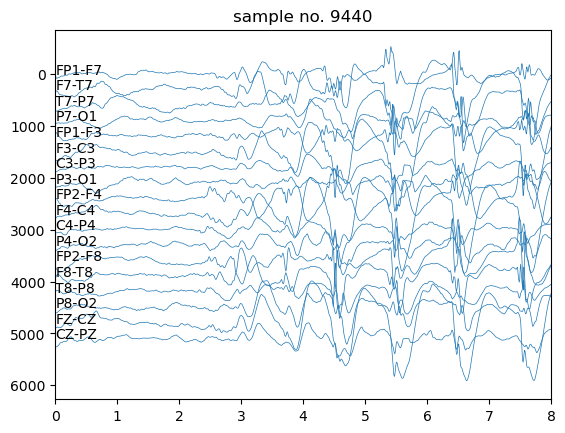

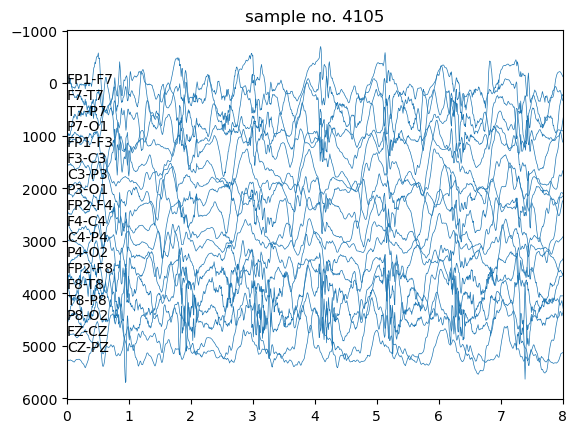

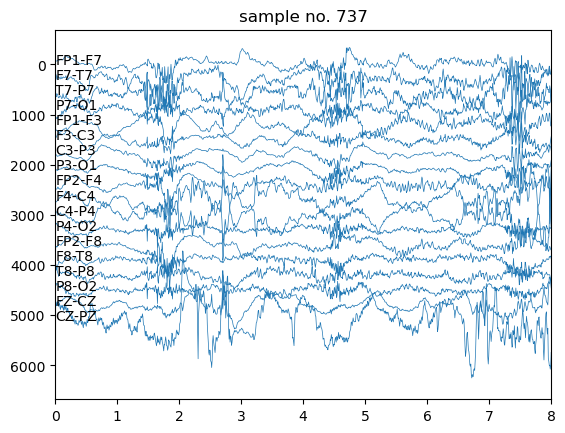

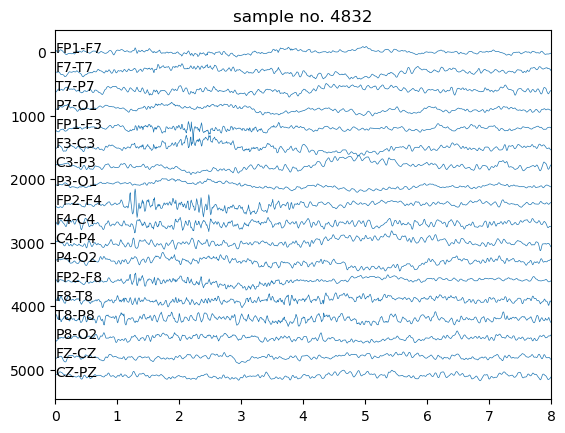

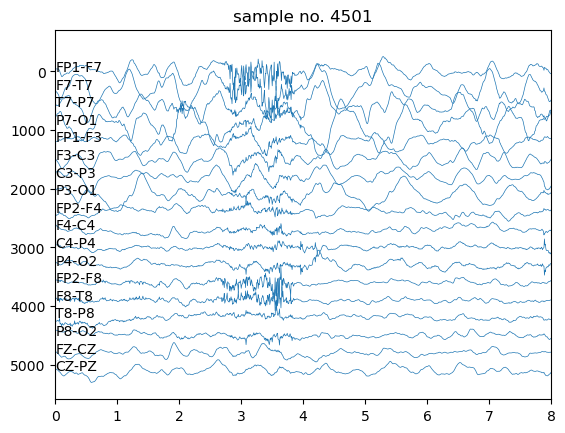

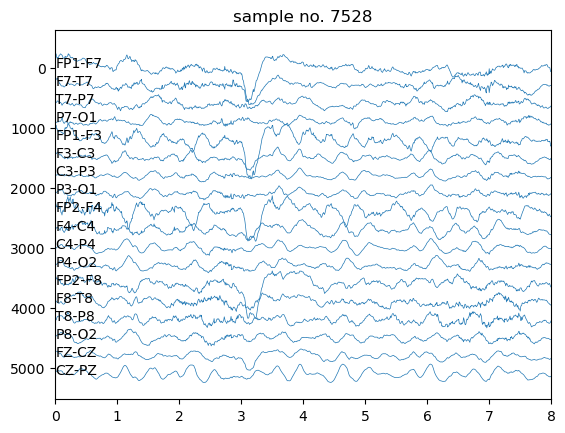

In [23]:
for n in random.sample(list(array_n),10):
    vertical_width = 300
    temp_signals = array_signals[n,:,:]
    fs = 128
    
    fig,ax = plt.subplots()
    for i in range(temp_signals.shape[0]):
        ax.plot(np.arange(temp_signals.shape[-1])/fs,temp_signals[i,:]+i*vertical_width,linewidth=0.5,color='tab:blue')
        ax.annotate(ch_labels[i],xy=(0,i*vertical_width))
    ax.invert_yaxis()
    ax.set_xlim(0,8)
    ax.set_title('sample no. {}'.format(n))
    
    plt.show()

In [24]:
array_signals = array_signals[:,:,:,np.newaxis]
array_signals.shape

(9505, 18, 2048, 1)

In [25]:
X_train,X_val,y_train,y_val = model_selection.train_test_split(
   array_signals,array_is_sz,test_size=0.3,stratify=(array_is_sz>0))

del array_signals , array_is_sz

In [26]:
X_train.shape, y_train.shape, X_val.shape, y_val.shape

((6653, 18, 2048, 1), (6653,), (2852, 18, 2048, 1), (2852,))

In [27]:
class ConvNet(nn.Module):
    def __init__(self):
        super(ConvNet, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=64, kernel_size=(2, 4), padding=(1, 1))
        self.conv2 = nn.Conv2d(in_channels=64, out_channels=64, kernel_size=(2, 4), stride=(1, 2), padding=(1, 1))
        self.maxpool1 = nn.MaxPool2d(kernel_size=(1, 2))
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=(2, 4), padding=(1, 1))
        self.conv4 = nn.Conv2d(in_channels=128, out_channels=128, kernel_size=(2, 4), stride=(1, 2), padding=(1, 1))
        self.maxpool2 = nn.MaxPool2d(kernel_size=(2, 2))
        self.conv5 = nn.Conv2d(in_channels=128, out_channels=256, kernel_size=(4, 4), padding=(1, 1))
        self.conv6 = nn.Conv2d(in_channels=256, out_channels=256, kernel_size=(4, 4), stride=(1, 2), padding=(1, 1))
        self.maxpool3 = nn.MaxPool2d(kernel_size=(1, 2))
        self.global_avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc1 = nn.Linear(256, 256)
        self.dropout1 = nn.Dropout(0.25)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 64)
        self.dropout2 = nn.Dropout(0.25)
        self.fc4 = nn.Linear(64, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.conv1(x)
        x = nn.functional.relu(x)
        x = self.conv2(x)
        x = nn.functional.relu(x)
        x = self.maxpool1(x)
        x = self.conv3(x)
        x = nn.functional.relu(x)
        x = self.conv4(x)
        x = nn.functional.relu(x)
        x = self.maxpool2(x)
        x = self.conv5(x)
        x = nn.functional.relu(x)
        x = self.conv6(x)
        x = nn.functional.relu(x)
        x = self.maxpool3(x)
        x = self.global_avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = nn.functional.relu(x)
        x = self.dropout1(x)
        x = self.fc2(x)
        x = nn.functional.relu(x)
        x = self.fc3(x)
        x = nn.functional.relu(x)
        x = self.dropout2(x)
        x = self.fc4(x)
        x = self.sigmoid(x)
        return x

model = ConvNet()
print(model)

ConvNet(
  (conv1): Conv2d(1, 64, kernel_size=(2, 4), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(64, 64, kernel_size=(2, 4), stride=(1, 2), padding=(1, 1))
  (maxpool1): MaxPool2d(kernel_size=(1, 2), stride=(1, 2), padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(2, 4), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(128, 128, kernel_size=(2, 4), stride=(1, 2), padding=(1, 1))
  (maxpool2): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  (conv5): Conv2d(128, 256, kernel_size=(4, 4), stride=(1, 1), padding=(1, 1))
  (conv6): Conv2d(256, 256, kernel_size=(4, 4), stride=(1, 2), padding=(1, 1))
  (maxpool3): MaxPool2d(kernel_size=(1, 2), stride=(1, 2), padding=0, dilation=1, ceil_mode=False)
  (global_avgpool): AdaptiveAvgPool2d(output_size=(1, 1))
  (fc1): Linear(in_features=256, out_features=256, bias=True)
  (dropout1): Dropout(p=0.25, inplace=False)
  (fc2): Linear(in_features=256, out_features=128, bias=True)

In [28]:
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(),lr=1e-4)

In [29]:
class MyDataset(Dataset):
    def __init__(self,X,y):
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).float()
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self,idx):
        return self.X[idx],self.y[idx]

In [30]:
train_dataset = MyDataset(X_train,y_train)
val_dataset = MyDataset(X_val,y_val)

In [31]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

In [ ]:
# !pip3 install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
num_epochs = 10
verbose=1
best_val_loss =  float('inf')
best_epoch = 0
model = model.to('cpu')
train_losses = []
val_losses=[]

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    for inputs,labels in train_loader:
        inputs = inputs.to('cpu')
        labels = labels.to('cpu')
        optimizer.zero_grad()
        inputs=inputs.permute(0,3,1,2)
        outputs = model(inputs)
        loss = criterion(outputs,labels.unsqueeze(1))
        loss.backward()
        optimizer.step()
        train_loss +=loss.item()*inputs.size(0)
    train_loss /= len(train_loader.dataset)
    train_losses.append(train_loss)
    
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for inputs,labels in val_loader:
            inputs = inputs.to('cpu')
            labels = labels.to('cpu')
            optimizer.zero_grad()
            inputs=inputs.permute(0, 3, 1, 2)
            outputs = model(inputs)
            loss = criterion(outputs,labels.unsqueeze(1))
            val_loss+=loss.item()*inputs.size(0)
        val_loss/=len(val_loader.dataset)
    val_losses.append(val_loss)
    
    if verbose:
        print(f'Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}')
    
    if val_loss<best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch
    elif epoch - best_epoch > 10:
        print(f'Early stopping at epoch {epoch+1}')
        break

plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

torch.save(model.state_dict(),'cnn_model.pth')

In [35]:
def sampling_data_pred(f, verbose=True):
    list_signals = []
    list_is_sz = []
    #n_sample = 40
    if verbose==True:
        print('{}: Reading. '.format(f))
    temp_edf =  mne.io.read_raw_edf(f)
    temp_labels = temp_edf.ch_names
    if sum([any([0 if re.match(c, l)==None else 1 for l in temp_edf.ch_names]) for c in ch_labels])==len(ch_labels):
        ch_mapping = {sorted([l for l in temp_edf.ch_names if re.match(c, l)!=None ])[0]:c for c in ch_labels}
        temp_edf.rename_channels(ch_mapping)
        #temp_edf = temp_edf.pick(ch_labels)

        temp_is_sz = np.zeros((temp_edf.n_times,))
        temp_signals = temp_edf.get_data(picks=ch_labels)*1e6

        if os.path.exists(f+'.seizures'):
            if verbose==True:
                print('sz exists.', end=' ')
            temp_annotation = wfdb.rdann(f, 'seizures')
            for i in range(int(temp_annotation.sample.size/2)):
                temp_is_sz[temp_annotation.sample[i*2]:temp_annotation.sample[i*2+1]]=1
        #else:
            #print('No sz.', end=' ')

        temp_len = temp_edf.n_times

        time_window = 8
        time_step = 4
        fs = int(1/(temp_edf.times[1]-temp_edf.times[0]))
        step_window = time_window*fs
        step = time_step*fs

        # sampling all signals
        temp_array_signals = np.array([temp_signals[:, i*step:i*step+step_window] for i in range((temp_len-step_window)//step)])
        temp_is_sz_ind = np.array([temp_is_sz[i*step:i*step+step_window].sum()/step_window for i in range((temp_len-step_window)//step)])
    else:
        if verbose==True:
            print('EEG {}: Not appropriate channel labels. Reading skipped.'.format(n))

    return temp_array_signals, temp_is_sz_ind

In [1]:
# reading files and prediction for 50 files

list_pred = []
list_true = []
test_losses = []

for f in tqdm.tqdm(files_test[:50]):
    array_signals, array_is_sz = sampling_data_pred(f, verbose=False)
    array_signals = array_signals[:, :, ::2, np.newaxis]
    test_dataset = MyDataset(array_signals,array_is_sz)
    test_loader = DataLoader(test_dataset, batch_size=32)    
    model.eval()
    test_loss = 0.0
    with torch.no_grad():
        for inputs,labels in test_loader:
            inputs = inputs.to('cpu')
            labels = labels.to('cpu')
            optimizer.zero_grad()
            inputs=inputs.permute(0, 3, 1, 2)
            outputs = model(inputs)
            loss = criterion(outputs,labels.unsqueeze(1))
            test_loss+=loss.item()*inputs.size(0)
            list_pred.append(outputs.detach().cpu().numpy())
            list_true.append(labels.detach().cpu().numpy())
        test_loss/=len(test_loader.dataset)
        test_losses.append(test_loss)
        
print(f'Avg Test Loss: {np.sum(test_losses)/len(test_losses):.6f}')

NameError: name 'tqdm' is not defined

In [ ]:
report = metrics.classification_report(np.concatenate(list_true)>0, np.concatenate(list_pred)>.5)
print(report)

In [ ]:
roc = metrics.roc_curve(np.concatenate(list_true)>0, np.concatenate(list_pred))
auc = metrics.roc_auc_score(np.concatenate(list_true)>0, np.concatenate(list_pred))

In [ ]:
plt.figure(figsize=(4, 4))
plt.plot(roc[0][np.argmin(np.abs(roc[2]-1)):], roc[1][np.argmin(np.abs(roc[2]-1)):])
plt.xlabel('FPR: false positive rate')
plt.ylabel('TPR: true positive rate')
plt.title('ROC curve: AUC score = {:.2f}'.format(auc))

th = [.1, .2, .5, .9, .95, 1.]
ind = [np.argmin(np.abs(roc[2]-l)) for l in th]
plt.scatter(roc[0][ind], roc[1][ind], s=15)
for i, l in enumerate(ind):
    plt.annotate("{}".format(th[i]), xy=(roc[0][l], roc[1][l]))
#plt.plot([0, 1, 1, 0, 0], [0, 0, 1, 1, 0], color='black', linewidth=1)
plt.ylim(-.05, 1.05)
plt.xlim(-.05, 1.05)
plt.grid()
#plt.axis('off')
plt.show()

In [ ]:
for i, f in enumerate(files_test):
    if os.path.exists(f+'.seizures'):
        print('Index = {} has seizures: {}'.format(i, f))

In [ ]:
def moving_ave(a, n):
    if len(a.shape)!=1:
        print('Not 1 dimension array. return nothing.')
        return
    temp = np.zeros(a.size-n)
    for i in range(n):
        temp = temp+a[i:-n+i]
    temp = temp/n
    
    return temp

In [ ]:
# get signals and labels from test data.
n=100
array_signals, array_is_sz = sampling_data_pred(files_test[n])

# preprocess
array_signals=array_signals[:, :, ::2, np.newaxis]


list_pred = []
list_true = [] 

test_dataset = MyDataset(array_signals,array_is_sz)
test_loader = DataLoader(test_dataset, batch_size=32)    
model.eval()
test_loss = 0.0
with torch.no_grad():
    for inputs,labels in test_loader:
        inputs = inputs.to('cuda')
        labels = labels.to('cuda')
        optimizer.zero_grad()
        inputs=inputs.permute(0, 3, 1, 2)
        outputs = model(inputs)
        loss = criterion(outputs,labels.unsqueeze(1))
        test_loss+=loss.item()*inputs.size(0)
        list_pred.extend(outputs.detach().cpu().numpy())
        list_true.extend(labels.detach().cpu().numpy())
    test_loss/=len(test_loader.dataset)
    test_losses.append(test_loss)

In [ ]:
pred = np.array(list_pred)
true = np.array(list_true)

In [ ]:
time_window = 8
time_step = 4
mv_win = 3

fig, ax = plt.subplots(figsize=(12, 2))

ax.plot(np.arange((pred.size))*time_step, pred.flatten(), alpha=0.7, label='deep learning model pred')
ax.plot(np.arange(pred.size)*time_step, true, alpha=.7, label='True label')

pred_moving_ave = moving_ave(pred.flatten(), mv_win)
pred_peaks, _ = find_peaks(pred_moving_ave, height=.95, distance=6)
ax.plot(np.arange(pred.size-mv_win)*time_step, pred_moving_ave,
        alpha=.9, label='pred - moving ave', color='tab:pink', zorder=0)
ax.scatter(pred_peaks*time_step, pred_moving_ave[pred_peaks], s=20, color='tab:red')

ax.set_xlabel('time (s)')
ax.set_ylabel('p')
ax.set_xlim(0, pred.size*time_step+500)
ax.legend(loc='upper right')
plt.show()

In [ ]:
if pred_peaks.size==0:
    print('No seizure detected.')
else:
    f = files_test[n]
    temp_edf =  mne.io.read_raw_edf(f)
    temp_labels = temp_edf.ch_names
    if sum([any([0 if re.match(c, l)==None else 1 for l in temp_edf.ch_names]) for c in ch_labels])==len(ch_labels):
        ch_mapping = {sorted([l for l in temp_edf.ch_names if re.match(c, l)!=None ])[0]:c for c in ch_labels}
        temp_edf.rename_channels(ch_mapping)
        #temp_edf = temp_edf.pick(ch_labels)

        temp_is_sz = np.zeros((temp_edf.n_times,))
        temp_signals = temp_edf.get_data(picks=ch_labels)*1e6

    fs = int(1/(temp_edf.times[1]-temp_edf.times[0]))
    for n_peak in range(pred_peaks.size):
        ind_peak = pred_peaks[n_peak]*time_step*fs
        backward_steps = 30*fs
        forward_steps = 15*fs
        vertical_width=500

        fig, ax = plt.subplots(figsize=(10, 6))
        for i in range(temp_signals.shape[0]):
            ax.plot(np.arange(ind_peak-backward_steps, ind_peak+forward_steps)/fs,
                    temp_signals[i, ind_peak-backward_steps:ind_peak+forward_steps]+i*vertical_width, linewidth=0.5, color='tab:blue')
            ax.annotate(ch_labels[i], xy=((ind_peak-backward_steps)/fs, i*vertical_width))
        ax.axvline(x=ind_peak/fs, color='tab:red', alpha=0.5, label='Seizure detection point')
        ax.invert_yaxis()
        ax.legend(loc='upper right')
        plt.show()
    #ax.set_xlim(0, 8)

    temp_edf.close()